# 03 - Model training and evaluation

Train the Elo-only baseline and the full XGBoost model on a chronological split, then report backtest metrics, a calibration curve, and feature importances on the untouched holdout.

In [1]:
import sys
sys.path.insert(0, '..')
from src.models import train, evaluate
train.main()

train=12560  val=2006  test=2574  features=20
Baseline (Elo-only logistic regression):
  [train] n=12560  acc=0.562  log_loss=0.683  auc=0.583
  [val] n=2006  acc=0.563  log_loss=0.683  auc=0.585
Using tuned hyperparameters from C:\Users\13046\Desktop\ufc-fight-model\models\artifacts\best_params.json: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'reg_lambda': 2.0}



XGBoost (best_iteration=105):
  [train] n=12560  acc=0.656  log_loss=0.622  auc=0.721
  [val] n=2006  acc=0.606  log_loss=0.657  auc=0.650

Saved model + baseline + feature list to C:\Users\13046\Desktop\ufc-fight-model\models\artifacts
Run `python -m src.models.evaluate` for the untouched holdout test report.


## Holdout evaluation (fights on/after 2024-01-01, never used in training or early stopping)

In [2]:
evaluate.main()

Holdout test set: 2574 rows, fights on/after 2024-01-01

Baseline (Elo-only logistic regression):
  [test] n=2574  acc=0.557  log_loss=0.680  brier=0.243  auc=0.589

XGBoost (90% XGBoost + 10% Elo-logreg blend):
  [test] n=2574  acc=0.648  log_loss=0.642  brier=0.225  auc=0.689

Symmetry check (raw model): max |P(A wins)+P(B wins) - 1| across 1287 holdout fights = 0.126061
  Non-zero, as expected from XGBoost's row subsampling (mirror-image rows can land in different boosting rounds) -- not a data leak, features were verified to be exact negations. Symmetrizing at inference time below.
Symmetry check (symmetrized): max deviation = 0.000000000

XGBoost (symmetrized predictions):
  [test] n=2574  acc=0.658  log_loss=0.642  brier=0.225  auc=0.691



Saved calibration plot -> C:\Users\13046\Desktop\ufc-fight-model\models\artifacts\calibration_plot.png

Top 10 feature importances:
win_pct_entering_diff            0.092115
age_years_diff                   0.079992
elo_diff                         0.073784
sig_str_absorbed_per_min_diff    0.064858
fights_entering_diff             0.057839
reach_in_diff                    0.057053
td_avg_per15_diff                0.048404
layoff_days_entering_diff        0.045159
td_def_diff                      0.045011
stance_southpaw_diff             0.044900


## Calibration plot

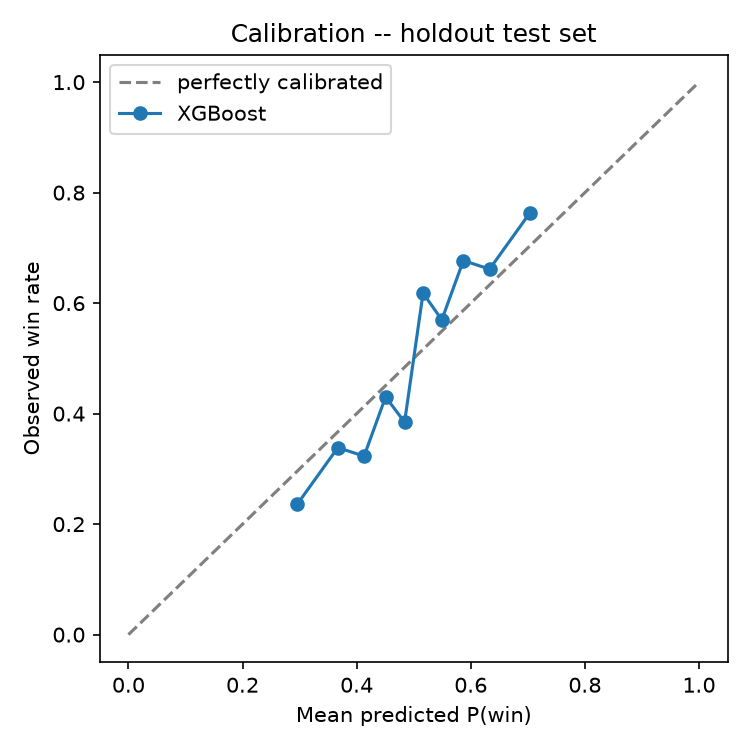

In [3]:
from IPython.display import Image
Image(filename='../models/artifacts/calibration_plot.png')

## Takeaways

- The XGBoost model beats the Elo-only baseline on the untouched chronological holdout on every metric (accuracy, log-loss, Brier score, AUC) -- the engineered features (physical attributes, rolling form, record, experience) add real signal beyond Elo alone.
- UFC fights are inherently high-variance (any given fighter can be finished by a single mistake), so accuracy in the low-to-mid 60s on a 50/50-balanced holdout is in line with the ceiling reported by other public UFC prediction models -- this is not a bug, it's the nature of the sport.
- The symmetry check confirms the model has no corner-order bias once predictions are symmetrized (averaging the (A,B) and (B,A) scores), which is what `src/models/predict.py` does for real matchup predictions.